Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import joblib
import warnings
warnings.filterwarnings('ignore')

Load Data

In [3]:
train_df = pd.read_csv('../data/train_motion_data.csv')
test_df = pd.read_csv('../data/test_motion_data.csv')

print("Training Data Shape:", train_df.shape)
print("Testing Data Shape:", test_df.shape)
train_df.head()

Training Data Shape: (3644, 8)
Testing Data Shape: (3084, 8)


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631


Exploratory Data Analysis

Missing values: 
 AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64


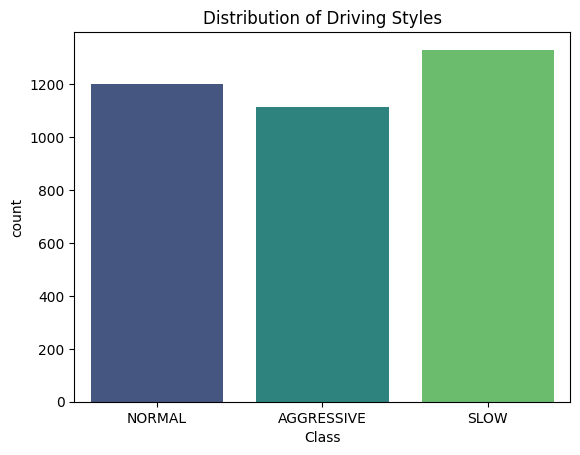

              AccX         AccY         AccZ        GyroX        GyroY  \
count  3644.000000  3644.000000  3644.000000  3644.000000  3644.000000   
mean      0.040467    -0.073418     0.008271     0.001593    -0.001273   
std       0.985653     0.903408     0.985061     0.066918     0.126205   
min      -4.636523    -4.699795    -7.143998    -0.751822    -1.587028   
25%      -0.550695    -0.592540    -0.558464    -0.028558    -0.053756   
50%       0.003931    -0.080833     0.002262     0.001985    -0.001833   
75%       0.595987     0.452401     0.556157     0.031918     0.051313   
max       4.985548     4.245151     5.171739     0.849255     1.679879   

             GyroZ     Timestamp  
count  3644.000000  3.644000e+03  
mean      0.007949  3.582707e+06  
std       0.115687  6.421479e+02  
min      -1.236468  3.581629e+06  
25%      -0.029398  3.582121e+06  
50%       0.002978  3.582702e+06  
75%       0.040852  3.583270e+06  
max       1.190500  3.583791e+06  


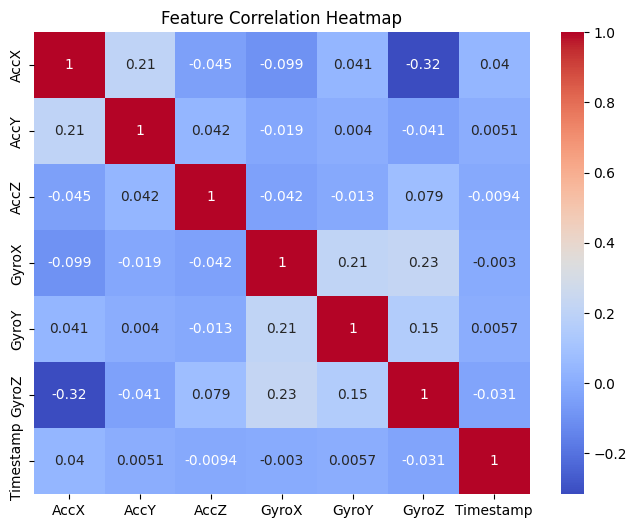

In [4]:
# Check for missing values
print("Missing values: \n", train_df.isnull().sum())

# Target Distribution
sns.countplot(x='Class', data=train_df, palette='viridis')
plt.title('Distribution of Driving Styles')
plt.show()

# Summary Statistics
print(train_df.describe())

# Correlation heatmap (use only numeric columns to avoid string -> float errors)
plt.figure(figsize=(8, 6))
numeric_df = train_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

Feature Engineering

In [9]:
#Sort timestamp in ascending order
train_df = train_df.sort_values('Timestamp').reset_index(drop=True)
test_df = test_df.sort_values('Timestamp').reset_index(drop=True)

# Acceleration and Gyroscope Magnitudes
train_df['acc_magnitude'] = np.sqrt(train_df['AccX']**2 + train_df['AccY']**2 + train_df['AccZ']**2)
test_df['acc_magnitude'] = np.sqrt(test_df['AccX']**2 + test_df['AccY']**2 + test_df['AccZ']**2)

train_df['gyro_magnitude'] = np.sqrt(train_df['GyroX']**2 + train_df['GyroY']**2 + train_df['GyroZ']**2) 
test_df['gyro_magnitude'] = np.sqrt(test_df['GyroX']**2 + test_df['GyroY']**2 + test_df['GyroZ']**2)

# Rolling Statistics
for window in [3, 5, 7]:
    train_df[f'acc_mean_w{window}'] = train_df['acc_magnitude'].rolling(window=window).mean() 
    train_df[f'acc_std_w{window}'] = train_df['acc_magnitude'].rolling(window=window).std() 
    test_df[f'acc_mean_w{window}'] = test_df['acc_magnitude'].rolling(window=window).mean() 
    test_df[f'acc_std_w{window}'] = test_df['acc_magnitude'].rolling(window=window).std()
    
# Drop rows with NaN values generated by rolling calculations
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

# Jerk Calculation
train_df['jerk'] = np.gradient(train_df['acc_magnitude'], train_df['Timestamp']) 
test_df['jerk'] = np.gradient(test_df['acc_magnitude'], test_df['Timestamp'])

# Angular Velocity Change Rate
train_df['gyro_jerk'] = np.gradient(train_df['gyro_magnitude'], train_df['Timestamp']) 
test_df['gyro_jerk'] = np.gradient(test_df['gyro_magnitude'], test_df['Timestamp'])

# Check results
print("Feature engineering complete. New columns added:")
print([col for col in train_df.columns if col not in ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ','Class','Timestamp']])

Feature engineering complete. New columns added:
['Class_encoded', 'acc_magnitude', 'gyro_magnitude', 'acc_mean_w3', 'acc_std_w3', 'acc_mean_w5', 'acc_std_w5', 'acc_mean_w7', 'acc_std_w7', 'jerk', 'gyro_jerk']


Preprocessing

In [14]:
# Encode target labels
label_encoder = LabelEncoder()
train_df['Class_encoded'] = label_encoder.fit_transform(train_df['Class'])

# Feature and target split
feature_cols = [col for col in train_df.columns if col not in ['Class', 'Class_encoded', 'Timestamp']]
X = train_df[feature_cols]
y = train_df['Class_encoded']

# Split for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Replace infinite values with NaN
for df in [X_train, X_val, test_df]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
test_scaled = scaler.transform(test_df[feature_cols])
print("Data preprocessing complete.")

Data preprocessing complete.


Model Training and Evaluation

In [15]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    print("\nClassification Report:\n", classification_report(y_val, y_pred))
    print("Accuracy:", accuracy_score(y_val, y_pred))
    print("Precision:", precision_score(y_val, y_pred, average='weighted'))
    print("Recall:", recall_score(y_val, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_val, y_pred, average='weighted'))
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

Try Baseline Models

Evaluating Logistic Regression...

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.56      0.55       223
           1       0.28      0.05      0.09       239
           2       0.45      0.76      0.56       266

    accuracy                           0.47       728
   macro avg       0.42      0.46      0.40       728
weighted avg       0.42      0.47      0.40       728

Accuracy: 0.46565934065934067
Precision: 0.4208637301445209
Recall: 0.46565934065934067
F1 Score: 0.4031573386449227


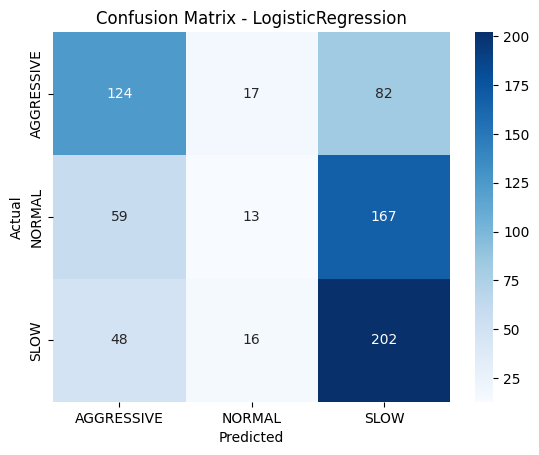

Evaluating Random Forest...

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.55      0.54       223
           1       0.45      0.38      0.42       239
           2       0.49      0.54      0.51       266

    accuracy                           0.49       728
   macro avg       0.49      0.49      0.49       728
weighted avg       0.49      0.49      0.49       728

Accuracy: 0.49313186813186816
Precision: 0.49094186002543905
Recall: 0.49313186813186816
F1 Score: 0.4906483920255758


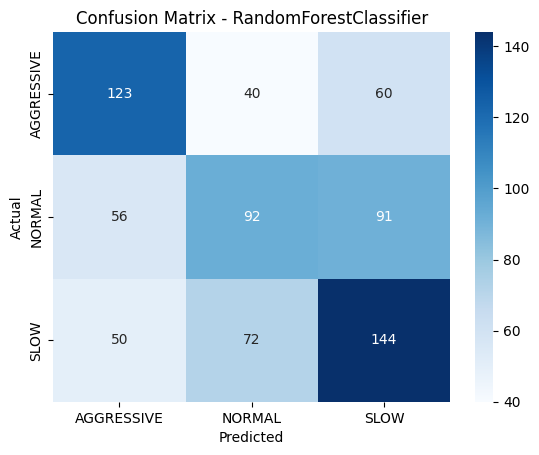

Evaluating Support Vector Machine...

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.56      0.57       223
           1       0.41      0.20      0.27       239
           2       0.45      0.68      0.54       266

    accuracy                           0.48       728
   macro avg       0.48      0.48      0.46       728
weighted avg       0.48      0.48      0.46       728

Accuracy: 0.4848901098901099
Precision: 0.4803509807531441
Recall: 0.4848901098901099
F1 Score: 0.4620181328049225


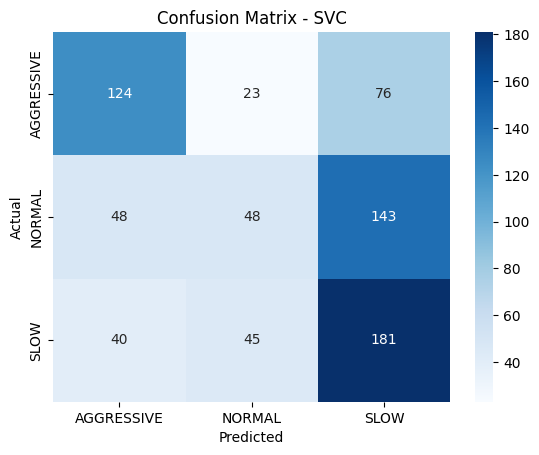

Evaluating XGBoost...

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.52      0.53       223
           1       0.41      0.46      0.44       239
           2       0.48      0.44      0.46       266

    accuracy                           0.47       728
   macro avg       0.48      0.48      0.48       728
weighted avg       0.48      0.47      0.47       728

Accuracy: 0.4739010989010989
Precision: 0.4779922288212304
Recall: 0.4739010989010989
F1 Score: 0.47498082507526657


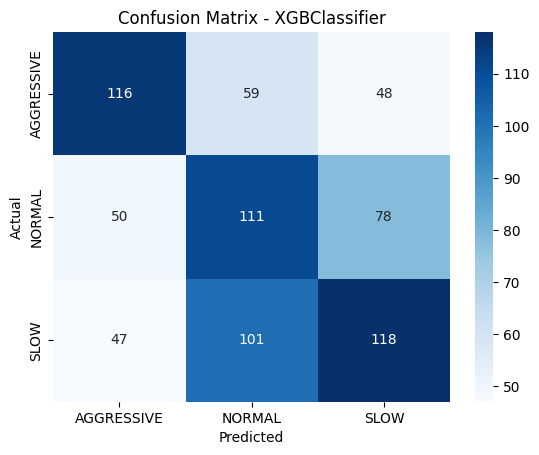

In [16]:
# Logistic Regression
print("Evaluating Logistic Regression...")
evaluate_model(LogisticRegression(max_iter=500), X_train_scaled, y_train, X_val_scaled, y_val)

# Random Forest
print("Evaluating Random Forest...")
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

# Support Vector Machine
print("Evaluating Support Vector Machine...")
evaluate_model(SVC(kernel='rbf', C=1, gamma='scale'), X_train_scaled, y_train, X_val_scaled, y_val)

# XGBoost
print("Evaluating XGBoost...")
evaluate_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), X_train_scaled, y_train, X_val_scaled, y_val)

Hyperparameter Tuning

Tuning Logistic Regression...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Tuning Random Forest...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Tuning Support Vector Machine...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for Support Vector Machine: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Tuning XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}

Tuned Model Comparison:
                     Model  CV F1 (weighted)  \
1           Random Forest          0.505841   
3                 XGBoost          0.498543   
2  Support Vector Machine          0.460167   
0     Logistic Regression     

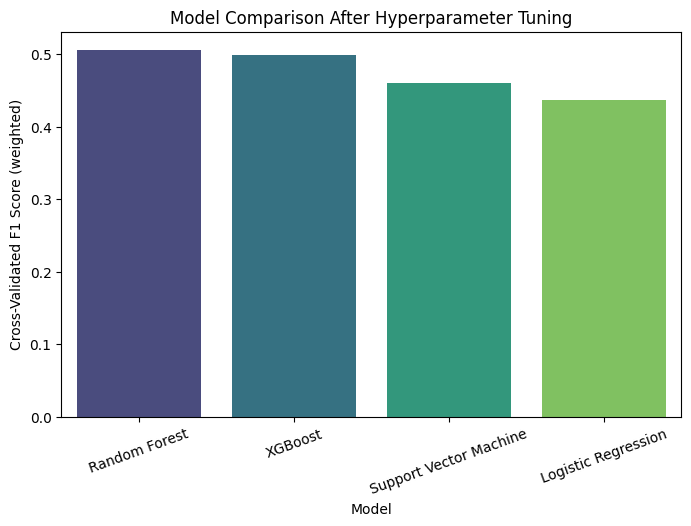

Best model after tuning: Random Forest

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.57      0.56       223
           1       0.47      0.31      0.38       239
           2       0.48      0.61      0.54       266

    accuracy                           0.50       728
   macro avg       0.50      0.50      0.49       728
weighted avg       0.50      0.50      0.49       728

Accuracy: 0.5
Precision: 0.4972175528104221
Recall: 0.5
F1 Score: 0.4910097815381387


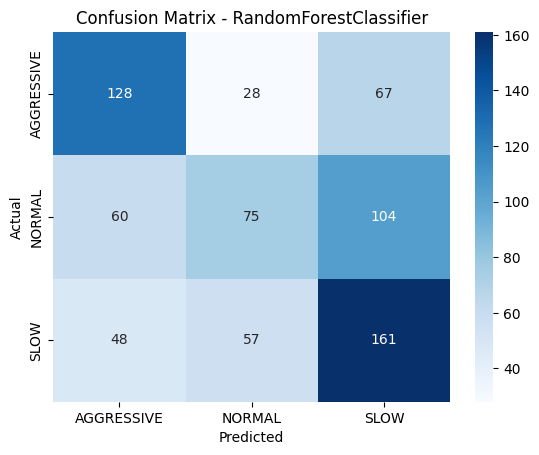

In [17]:
tuned_models = {}
results_summary = []

# Logistic Regression
print("Tuning Logistic Regression...")
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
lr = LogisticRegression(max_iter=500, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_lr.fit(X_train_scaled, y_train)

tuned_models['Logistic Regression'] = grid_lr.best_estimator_
results_summary.append(['Logistic Regression', grid_lr.best_score_, grid_lr.best_params_])
print("Best parameters for Logistic Regression:", grid_lr.best_params_)

# Random Forest
print("Tuning Random Forest...")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

tuned_models['Random Forest'] = grid_rf.best_estimator_
results_summary.append(['Random Forest', grid_rf.best_score_, grid_rf.best_params_])
print("Best parameters for Random Forest:", grid_rf.best_params_)

# Support Vector Machine
print("Tuning Support Vector Machine...")
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly']
}
svm_model = SVC(probability=True, random_state=42)
grid_svm = GridSearchCV(svm_model, param_grid_svm, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_svm.fit(X_train_scaled, y_train)

tuned_models['Support Vector Machine'] = grid_svm.best_estimator_
results_summary.append(['Support Vector Machine', grid_svm.best_score_, grid_svm.best_params_])
print("Best parameters for Support Vector Machine:", grid_svm.best_params_)

# XGBoost
print("Tuning XGBoost...")
param_grid_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'n_estimators': [300, 500, 800],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_scaled, y_train)

tuned_models['XGBoost'] = grid_xgb.best_estimator_
results_summary.append(['XGBoost', grid_xgb.best_score_, grid_xgb.best_params_])
print("Best parameters for XGBoost:", grid_xgb.best_params_)

# Compare tuned model results
results_df = pd.DataFrame(results_summary, columns=['Model', 'CV F1 (weighted)', 'Best Params'])
results_df = results_df.sort_values(by='CV F1 (weighted)', ascending=False)
print("\nTuned Model Comparison:\n", results_df)

# Plot comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='CV F1 (weighted)', data=results_df, palette='viridis')
plt.title('Model Comparison After Hyperparameter Tuning')
plt.ylabel('Cross-Validated F1 Score (weighted)')
plt.xticks(rotation=20)
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]
print(f"Best model after tuning: {best_model_name}")
evaluate_model(best_model, X_train_scaled, y_train, X_val_scaled, y_val)

Predict on Test Data

In [18]:
# Predict with best model
test_predictions = best_model.predict(test_scaled)
test_labels = label_encoder.inverse_transform(test_predictions)

# Save predictions
submission = pd.DataFrame({'timestamp': test_df['Timestamp'], 'predicted_driving_style': test_labels})
submission.to_csv('test_predictions.csv', index=False)
print("Predictions saved to test_predictions.csv")

# Save model and scaler
joblib.dump(best_model, 'best_driving_behavior_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Model, scaler, and label encoder saved.")



Predictions saved to test_predictions.csv
Model, scaler, and label encoder saved.
